## Protein Variant Effect Predictor

This project is a demonstration of multiple important bioinformatics tools that I used to interpret missense variants, including a novel variant with no clinical classification that I came across through my own variant-calling pipeline.

This workflow was run in Colab and uses the following tools:

*   ClinVar
*   UniProt
*   ESM-2
*   AlphaMissense
*   AlphaFold DB
*   py3Dmol
*   biotite/ PDB parsing
*   pandas / matplotlib

This project is a natural extension of my variant-calling workflow and can be found under germline-variant-pipeline on my GitHub.



In [33]:
import pandas as pd

# Creating the labeled variant set

I chose from a variety of well-documented variants that are known to be pathogenic or benign in ClinVar. I filtered for expert-panel and/or multi-submitter review status. I collected the following fields for each variant: gene, protein change, the HGVS nomenclature, label, review status, and the uniprot ID.

In [34]:
variants = [
    {"gene": "TP53", "protein_change": "p.Arg273His", "hgvs_c": "c.818G>A",
     "label": "Pathogenic", "review": "Expert panel", "uniprot": "P04637"},
    {"gene": "TP53", "protein_change": "p.Val272Met", "hgvs_c": "c.814G>A",
     "label": "Pathogenic", "review": "Expert panel", "uniprot": "P04637"},
    {"gene": "TP53", "protein_change": "p.Arg283Pro", "hgvs_c": "c.848G>C",
     "label": "Pathogenic", "review": "Expert panel", "uniprot": "P04637"},

    {"gene": "PTEN", "protein_change": "p.Asp24His", "hgvs_c": "c.70G>C",
     "label": "Pathogenic", "review": "Expert panel", "uniprot": "P60484"},
    {"gene": "PTEN", "protein_change": "p.Thr131Ile", "hgvs_c": "c.392C>T",
     "label": "Pathogenic", "review": "Expert panel", "uniprot": "P60484"},
    {"gene": "PTEN", "protein_change": "p.Arg173Cys", "hgvs_c": "c.517C>T",
     "label": "Pathogenic", "review": "Expert panel", "uniprot": "P60484"},

    {"gene": "BRCA1", "protein_change": "p.Gly1788Val", "hgvs_c": "c.5363G>T",
     "label": "Pathogenic", "review": "Expert panel", "uniprot": "P38398"},
    {"gene": "BRCA1", "protein_change": "p.Leu1786Pro", "hgvs_c": "c.5357T>C",
     "label": "Pathogenic", "review": "Expert panel", "uniprot": "P38398"},
    {"gene": "BRCA1", "protein_change": "p.Phe1761Ser", "hgvs_c": "c.5282T>C",
     "label": "Pathogenic", "review": "Expert panel", "uniprot": "P38398"},

     {"gene": "POFUT1", "protein_change": "p.Met24Leu", "hgvs_c": "c.70A>T",
     "label": "Likely benign", "review": "One star", "uniprot": "Q9H488"},
    {"gene": "POFUT1", "protein_change": "p.Leu322Phe", "hgvs_c": "c.964C>T",
     "label": "Benign", "review": "One star", "uniprot": "Q9H488"},
    {"gene": "POFUT1", "protein_change": "p.Asp348Asn", "hgvs_c": "c.1042G>A",
     "label": "Benign", "review": "One star", "uniprot": "Q9H488"},

    {"gene": "TOX2", "protein_change": "p.Met141Val", "hgvs_c": "c.421A>G",
     "label": "Likely benign", "review": "Multiple Submitters", "uniprot": "Q96NM4"},

    {"gene": "VSX1", "protein_change": "p.Asp144Glu", "hgvs_c": "c.432C>G",
     "label": "Benign/Likely benign", "review": "Multiple Submitters", "uniprot": "Q9NZR4"},

    {"gene": "RBBP8NL", "protein_change": "p.Pro539Thr", "hgvs_c": "c.1615C>A",
     "label": "Unknown", "review": "not_in_clinvar", "uniprot": "Q8NC74"},

]



In [35]:
variants_df = pd.DataFrame(variants)

In [36]:
variants_df

,gene,protein_change,hgvs_c,label,review,uniprot
0,TP53,p.Arg273His,c.818G>A,Pathogenic,Expert panel,P04637
1,TP53,p.Val272Met,c.814G>A,Pathogenic,Expert panel,P04637
2,TP53,p.Arg283Pro,c.848G>C,Pathogenic,Expert panel,P04637
3,PTEN,p.Asp24His,c.70G>C,Pathogenic,Expert panel,P60484
4,PTEN,p.Thr131Ile,c.392C>T,Pathogenic,Expert panel,P60484
5,PTEN,p.Arg173Cys,c.517C>T,Pathogenic,Expert panel,P60484
6,BRCA1,p.Gly1788Val,c.5363G>T,Pathogenic,Expert panel,P38398
7,BRCA1,p.Leu1786Pro,c.5357T>C,Pathogenic,Expert panel,P38398
8,BRCA1,p.Phe1761Ser,c.5282T>C,Pathogenic,Expert panel,P38398
9,POFUT1,p.Met24Leu,c.70A>T,Likely benign,One star,Q9H488


In [37]:
variants_df.to_csv("variants_dataset.csv", index=False)

# Fetching protein sequences and verifying positions

In [38]:
import requests

def fetch_uniprot_sequence(uniprot_id):
    """Fetch a protein's amino acid sequence from UniProt as a plain string."""
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta"
    response = requests.get(url)
    response.raise_for_status()
    # The FASTA format has a header line (starts with >) then sequence lines.
    # so drop the header and join the rest into one continuous string.
    lines = response.text.strip().split("\n")
    sequence = "".join(lines[1:])
    return sequence

# fetching sequences for each unique protein in the dataset created
unique_ids = variants_df["uniprot"].unique()
sequences = {}
for uid in unique_ids:
    sequences[uid] = fetch_uniprot_sequence(uid)
    print(f"{uid}: {len(sequences[uid])} amino acids")

P04637: 393 amino acids
P60484: 403 amino acids
P38398: 1863 amino acids
Q9H488: 388 amino acids
Q96NM4: 488 amino acids
Q9NZR4: 365 amino acids
Q8NC74: 664 amino acids


In [39]:
# Map three-letter amino acid codes to single-letter since ESM uses single-letter
aa3to1 = {
    'Ala':'A','Arg':'R','Asn':'N','Asp':'D','Cys':'C','Gln':'Q','Glu':'E',
    'Gly':'G','His':'H','Ile':'I','Leu':'L','Lys':'K','Met':'M','Phe':'F',
    'Pro':'P','Ser':'S','Thr':'T','Trp':'W','Tyr':'Y','Val':'V'
}

import re

def parse_protein_change(pc):
    """Parse 'p.Arg273His' -> ('R', 273, 'H')."""
    m = re.match(r'p\.([A-Za-z]{3})(\d+)([A-Za-z]{3})', pc)
    orig3, pos, mut3 = m.group(1), int(m.group(2)), m.group(3)
    return aa3to1[orig3], pos, aa3to1[mut3]

# Verify whether for each variant the sequences has the expected
# original amino acid at that position
for idx, row in variants_df.iterrows():
    seq = sequences[row["uniprot"]]
    orig, pos, mut = parse_protein_change(row["protein_change"])
    actual = seq[pos - 1]   # position is 1-based; Python strings are 0-based
    match = "CORRECT" if actual == orig else "MISMATCH"
    print(f"{row['gene']:8} {row['protein_change']:16} expected {orig} at {pos}, found {actual}  {match}")

TP53     p.Arg273His      expected R at 273, found R  CORRECT
TP53     p.Val272Met      expected V at 272, found V  CORRECT
TP53     p.Arg283Pro      expected R at 283, found R  CORRECT
PTEN     p.Asp24His       expected D at 24, found D  CORRECT
PTEN     p.Thr131Ile      expected T at 131, found T  CORRECT
PTEN     p.Arg173Cys      expected R at 173, found R  CORRECT
BRCA1    p.Gly1788Val     expected G at 1788, found G  CORRECT
BRCA1    p.Leu1786Pro     expected L at 1786, found L  CORRECT
BRCA1    p.Phe1761Ser     expected F at 1761, found F  CORRECT
POFUT1   p.Met24Leu       expected M at 24, found M  CORRECT
POFUT1   p.Leu322Phe      expected L at 322, found L  CORRECT
POFUT1   p.Asp348Asn      expected D at 348, found D  CORRECT
TOX2     p.Met141Val      expected M at 141, found S  MISMATCH
VSX1     p.Asp144Glu      expected D at 144, found D  CORRECT
RBBP8NL  p.Pro539Thr      expected P at 539, found P  CORRECT


TOX2 is the only mismatch. Most likely due to ClinVar using a different isoform of the gene for comparison.

In [40]:
# remove TOX2
variants = [v for v in variants if v["gene"] != "TOX2"]
df = pd.DataFrame(variants)

for idx, row in df.iterrows():
    seq = sequences[row["uniprot"]]
    orig, pos, mut = parse_protein_change(row["protein_change"])
    actual = seq[pos - 1]
    match = "OK" if actual == orig else "MISMATCH"
    print(f"{row['gene']:8} {row['protein_change']:16} {match}")

TP53     p.Arg273His      OK
TP53     p.Val272Met      OK
TP53     p.Arg283Pro      OK
PTEN     p.Asp24His       OK
PTEN     p.Thr131Ile      OK
PTEN     p.Arg173Cys      OK
BRCA1    p.Gly1788Val     OK
BRCA1    p.Leu1786Pro     OK
BRCA1    p.Phe1761Ser     OK
POFUT1   p.Met24Leu       OK
POFUT1   p.Leu322Phe      OK
POFUT1   p.Asp348Asn      OK
VSX1     p.Asp144Glu      OK
RBBP8NL  p.Pro539Thr      OK


# ESM variant scoring

In [41]:
!pip install fair-esm

import torch
import esm

# Pretrained ESM-2 model. Super cool ~150M-parameter protein language model.
model, alphabet = esm.pretrained.esm2_t30_150M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
print(f"Model loaded on {device}")

Model loaded on cuda


In [42]:
def esm_score(sequence, pos, wt, mut):
    """
    Score a variant via masked-marginal log-likelihood ratio.
    pos is 1-based; wt/mut are single-letter amino acids.
    Returns log P(mut) - log P(wt). Negative = mutant less likely = more damaging.
    """
    # ESM has a length limit; truncate a window around the variant if the protein is long
    max_len = 1022
    if len(sequence) > max_len:
        # center a window on the variant position
        half = max_len // 2
        start = max(0, pos - 1 - half)
        end = min(len(sequence), start + max_len)
        start = max(0, end - max_len)
        window_seq = sequence[start:end]
        pos_in_window = (pos - 1) - start + 1
    else:
        window_seq = sequence
        pos_in_window = pos

    data = [("protein", window_seq)]
    _, _, tokens = batch_converter(data)
    tokens = tokens.to(device)

    # Mask the variant position (token index is pos_in_window because of the start token at index 0)
    mask_idx = pos_in_window
    tokens_masked = tokens.clone()
    tokens_masked[0, mask_idx] = alphabet.mask_idx

    with torch.no_grad():
        logits = model(tokens_masked)["logits"]
    # log-probabilities over the vocabulary at the masked position
    log_probs = torch.log_softmax(logits[0, mask_idx], dim=-1)

    wt_score = log_probs[alphabet.get_idx(wt)].item()
    mut_score = log_probs[alphabet.get_idx(mut)].item()
    return mut_score - wt_score

# Run on all variants
scores = []
for idx, row in df.iterrows():
    seq = sequences[row["uniprot"]]
    wt, pos, mut = parse_protein_change(row["protein_change"])
    s = esm_score(seq, pos, wt, mut)
    scores.append(s)
    print(f"{row['gene']:8} {row['protein_change']:16} {row['label']:20} score: {s:+.2f}")

df["esm_score"] = scores

TP53     p.Arg273His      Pathogenic           score: -5.02
TP53     p.Val272Met      Pathogenic           score: -3.25
TP53     p.Arg283Pro      Pathogenic           score: -6.33
PTEN     p.Asp24His       Pathogenic           score: -9.49
PTEN     p.Thr131Ile      Pathogenic           score: -8.95
PTEN     p.Arg173Cys      Pathogenic           score: -8.65
BRCA1    p.Gly1788Val     Pathogenic           score: -8.41
BRCA1    p.Leu1786Pro     Pathogenic           score: -5.29
BRCA1    p.Phe1761Ser     Pathogenic           score: -9.10
POFUT1   p.Met24Leu       Likely benign        score: +3.83
POFUT1   p.Leu322Phe      Benign               score: -2.08
POFUT1   p.Asp348Asn      Benign               score: -2.40
VSX1     p.Asp144Glu      Benign/Likely benign score: -0.22
RBBP8NL  p.Pro539Thr      Unknown              score: -1.39


Key observations:


*   There is a clear distinction between pathogenic (negative) and benign variants (close to 0 or positive).
*   All variants of PTEN seem to be the most pathogenic of all (-8 to -9)
*   POFUT1 p.Met24Leu is the only strongly positive variant in the entire dataset which means that ESM was able to determine that Leucine is a very usual choice for that position in the gene. This is because both methionine and leucine are hydrophobic amino acids so one being swapped for another does not really cause a major change in the resulting protein.
*   RBBP8NL was the protein that I was on the lookout for the most. It came up as rare in HG002's chr20 but was not present in ClinVar at all. Although negative, ESM still classified it in the benign-ish range at -1.4 even though there is no database information on it.





In [43]:
df.to_csv("variants_with_esm.csv", index=False)

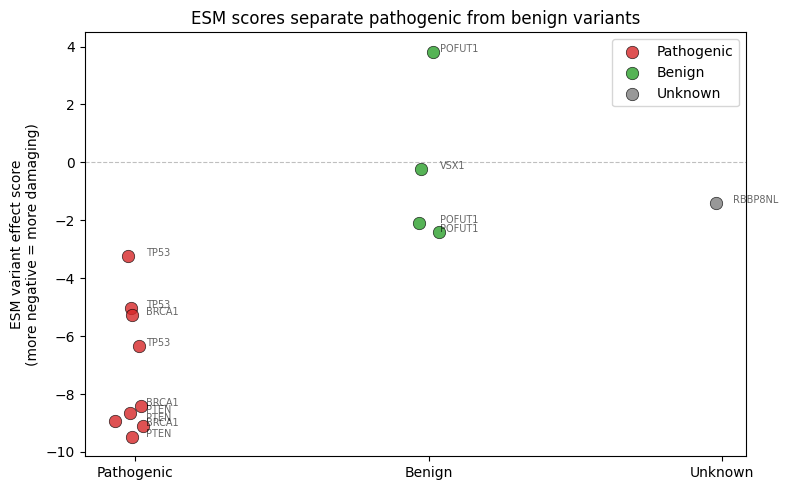

In [44]:
import matplotlib.pyplot as plt
import numpy as np

def category(label):
    if "Pathogenic" in label:
        return "Pathogenic"
    elif "benign" in label.lower() or "Benign" in label:
        return "Benign"
    else:
        return "Unknown"

df["category"] = df["label"].apply(category)

colors = {"Pathogenic": "#d62728", "Benign": "#2ca02c", "Unknown": "#7f7f7f"}

fig, ax = plt.subplots(figsize=(8, 5))


for cat in ["Pathogenic", "Benign", "Unknown"]:
    sub = df[df["category"] == cat]

    x = np.random.normal(loc={"Pathogenic":0, "Benign":1, "Unknown":2}[cat], scale=0.05, size=len(sub))
    ax.scatter(x, sub["esm_score"], color=colors[cat], s=80, label=cat, alpha=0.8, edgecolors="black", linewidth=0.5)


for idx, row in df.iterrows():
    xpos = {"Pathogenic":0, "Benign":1, "Unknown":2}[row["category"]]
    ax.annotate(row["gene"], (xpos, row["esm_score"]),
                fontsize=7, alpha=0.6, xytext=(8, 0), textcoords="offset points")

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Pathogenic", "Benign", "Unknown"])
ax.set_ylabel("ESM variant effect score\n(more negative = more damaging)")
ax.set_title("ESM scores separate pathogenic from benign variants")
ax.legend()
plt.tight_layout()
plt.show()

In [45]:
fig.savefig("esm_score_separation.png", dpi=150, bbox_inches="tight")

# AlphaMissense scoring

As a second, independent predictor, I used AlphaMissense (DeepMind's structure-informed pathogenicity model). Where ESM reasons purely from evolutionary sequence patterns, AlphaMissense incorporates predicted structure — so agreement between the two is a meaningful cross-check rather than two versions of the same method.

Rather than run the model directly (it is far too large and its scores are already pre-computed for nearly all human missense variants), I queried the Ensembl VEP REST API with AlphaMissense enabled, using each variant's canonical transcript and coding change. AlphaMissense returns a pathogenicity score from 0 to 1 (higher = more pathogenic), the opposite direction from ESM's score. Note this required correct per-gene transcript IDs and retry logic to handle API rate limiting.

In [46]:
import requests, time

server = "https://rest.ensembl.org"

canonical_transcript = {
    "TP53":   "ENST00000269305",
    "PTEN":   "ENST00000371953",
    "BRCA1":  "ENST00000357654",
    "POFUT1": "ENST00000375749",
    "VSX1":   "ENST00000376709",
    "RBBP8NL":"ENST00000252998",
}

def get_alphamissense(gene, hgvs_c, max_retries=4):
    tx = canonical_transcript[gene]
    ext = f"/vep/human/hgvs/{tx}:{hgvs_c}?AlphaMissense=1"
    for attempt in range(max_retries):
        r = requests.get(server + ext, headers={"Content-Type": "application/json"})
        if r.status_code == 200:
            data = r.json()
            for c in data[0].get("transcript_consequences", []):
                if c.get("transcript_id") == tx and "alphamissense" in c:
                    am = c["alphamissense"]
                    return am.get("am_pathogenicity"), am.get("am_class")
            return None, None  # 200 but no AM score (genuinely absent)
        elif r.status_code == 429:
            # rate limited — wait longer and retry
            wait = float(r.headers.get("Retry-After", 2))
            print(f"  {gene}: rate limited, waiting {wait}s...")
            time.sleep(wait)
        else:
            print(f"  {gene}: status {r.status_code}, retrying...")
            time.sleep(2)
    return None, None  # exhausted retries

am_scores, am_classes = [], []
for idx, row in df.iterrows():
    score, cls = get_alphamissense(row["gene"], row["hgvs_c"])
    am_scores.append(score)
    am_classes.append(cls)
    print(f"{row['gene']:8} {row['protein_change']:16} {row['label']:20} AM: {score}  ({cls})")
    time.sleep(1.5)   # longer polite pause between variants

df["am_pathogenicity"] = am_scores
df["am_class"] = am_classes

TP53     p.Arg273His      Pathogenic           AM: 0.9889  (likely_pathogenic)
  TP53: status 503, retrying...
TP53     p.Val272Met      Pathogenic           AM: 0.9572  (likely_pathogenic)
TP53     p.Arg283Pro      Pathogenic           AM: 0.9928  (likely_pathogenic)
PTEN     p.Asp24His       Pathogenic           AM: 0.9999  (likely_pathogenic)
PTEN     p.Thr131Ile      Pathogenic           AM: 0.9999  (likely_pathogenic)
PTEN     p.Arg173Cys      Pathogenic           AM: 0.9981  (likely_pathogenic)
BRCA1    p.Gly1788Val     Pathogenic           AM: 0.9249  (likely_pathogenic)
BRCA1    p.Leu1786Pro     Pathogenic           AM: 0.9609  (likely_pathogenic)
BRCA1    p.Phe1761Ser     Pathogenic           AM: 0.9848  (likely_pathogenic)
POFUT1   p.Met24Leu       Likely benign        AM: 0.0644  (likely_benign)
POFUT1   p.Leu322Phe      Benign               AM: 0.0772  (likely_benign)
POFUT1   p.Asp348Asn      Benign               AM: 0.1737  (likely_benign)
VSX1     p.Asp144Glu      Benign

In [47]:
df.to_csv("variants_with_esm_and_am.csv", index=False)

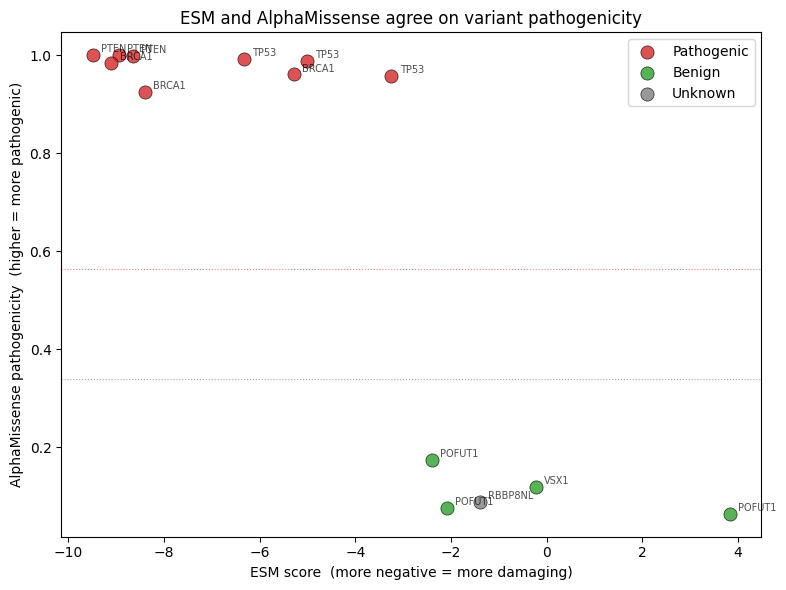

In [48]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))

colors = {"Pathogenic": "#d62728", "Benign": "#2ca02c", "Unknown": "#7f7f7f"}

for cat in ["Pathogenic", "Benign", "Unknown"]:
    sub = df[df["category"] == cat]
    ax.scatter(sub["esm_score"], sub["am_pathogenicity"],
               color=colors[cat], s=90, label=cat,
               alpha=0.8, edgecolors="black", linewidth=0.5)

# Label each point with its gene
for idx, row in df.iterrows():
    ax.annotate(row["gene"], (row["esm_score"], row["am_pathogenicity"]),
                fontsize=7, alpha=0.7, xytext=(6, 2), textcoords="offset points")

# Reference lines: AlphaMissense pathogenic/benign thresholds
ax.axhline(0.564, color="red",   linestyle=":", linewidth=0.8, alpha=0.5)
ax.axhline(0.340, color="green", linestyle=":", linewidth=0.8, alpha=0.5)

ax.set_xlabel("ESM score  (more negative = more damaging)")
ax.set_ylabel("AlphaMissense pathogenicity  (higher = more pathogenic)")
ax.set_title("ESM and AlphaMissense agree on variant pathogenicity")
ax.legend()
plt.tight_layout()
plt.show()

fig.savefig("esm_vs_alphamissense.png", dpi=150, bbox_inches="tight")

In [49]:
!pip install py3Dmol

# Structural analysis (AlphaFold)

To understand *why* the predictors score each variant as they do, I examined each variant's position in its predicted 3D structure, pulled from the AlphaFold Protein Structure Database.

An important caveat drove the approach here: AlphaFold is largely mutation-insensitive meaning that folding the wild-type and mutant sequences and comparing shapes would show almost no difference since a single substitution rarely changes the predicted backbone. So structure is used here
not to detect change, but to **locate** each variant and characterize its context. I check this two ways — visually (py3Dmol) and numerically, by reading the per-residue confidence (pLDDT) directly from the structure file.

In [50]:
def fetch_alphafold_structure(uniprot_id):
    """Get the AlphaFold structure via the API (handles version automatically)."""
    api = requests.get(f"https://alphafold.ebi.ac.uk/api/prediction/{uniprot_id}")
    api.raise_for_status()
    meta = api.json()[0]
    pdb_url = meta.get("pdbUrl")
    r = requests.get(pdb_url)
    r.raise_for_status()
    return r.text, meta

In [51]:
from google.colab import output
import py3Dmol

output.enable_custom_widget_manager()

def show_structure(pdb_text, highlight_positions=None):
    view = py3Dmol.view(width=700, height=500)
    view.addModel(pdb_text, "pdb")
    view.setStyle({"cartoon": {"color": "lightgrey"}})
    if highlight_positions:
        for pos in highlight_positions:
            view.addStyle({"resi": str(pos)},
                          {"stick": {"color": "red"},
                           "sphere": {"color": "red", "radius": 2}})
    view.zoomTo()
    return view



In [52]:
tp53_structure, tp53_meta = fetch_alphafold_structure("P04637")
view = show_structure(tp53_structure, highlight_positions=[272, 273, 283])
html = view._make_html()
from IPython.display import HTML
HTML(html)

In [53]:
pten_structure, pten_meta = fetch_alphafold_structure("P60484")
view = show_structure(pten_structure, highlight_positions=[24, 131, 173])
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [54]:
pofut1_structure, pofut1_meta = fetch_alphafold_structure("Q9H488")
view = show_structure(pofut1_structure, highlight_positions=[24, 322, 348])
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [55]:
rbbp8nl_structure, rbbp8nl_meta = fetch_alphafold_structure("Q8NC74")
view = show_structure(rbbp8nl_structure, highlight_positions=[539])
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Note: 3D structures rendered via py3Dmol; saved images in figures/

In [56]:
def analyze_positions_raw(pdb_text, positions, gene):
    """Read pLDDT directly from PDB text (B-factor is columns 61-66 in PDB format)."""

    from collections import defaultdict
    res_plddt = defaultdict(list)
    for line in pdb_text.split("\n"):
        if line.startswith("ATOM"):
            try:
                res_id = int(line[22:26])
                bfactor = float(line[60:66])   # pLDDT lives here in AlphaFold PDBs
                res_name = line[17:20].strip()
                res_plddt[(res_id, res_name)].append(bfactor)
            except (ValueError, IndexError):
                continue
    for pos in positions:
        matches = [(k, v) for k, v in res_plddt.items() if k[0] == pos]
        if not matches:
            print(f"{gene} pos {pos}: not found")
            continue
        (rid, rname), bfactors = matches[0]
        plddt = sum(bfactors) / len(bfactors)
        conf = "high" if plddt > 90 else "medium" if plddt > 70 else "LOW"
        print(f"{gene} pos {pos:4} ({rname}): pLDDT={plddt:.0f} ({conf})")

analyze_positions_raw(tp53_structure, [272, 273, 283], "TP53")
analyze_positions_raw(pten_structure, [24, 131, 173], "PTEN")
analyze_positions_raw(pofut1_structure, [24, 322, 348], "POFUT1")
analyze_positions_raw(rbbp8nl_structure, [539], "RBBP8NL")

TP53 pos  272 (VAL): pLDDT=99 (high)
TP53 pos  273 (ARG): pLDDT=99 (high)
TP53 pos  283 (ARG): pLDDT=96 (high)
PTEN pos   24 (ASP): pLDDT=94 (high)
PTEN pos  131 (THR): pLDDT=99 (high)
PTEN pos  173 (ARG): pLDDT=98 (high)
POFUT1 pos   24 (MET): pLDDT=58 (LOW)
POFUT1 pos  322 (LEU): pLDDT=96 (high)
POFUT1 pos  348 (ASP): pLDDT=99 (high)
RBBP8NL pos  539 (PRO): pLDDT=63 (LOW)
